In [2]:
from pathlib import Path
import sys

def _project_root() -> Path:
    here = Path.cwd().resolve()
    for p in [here, *here.parents]:
        if (p / "src" / "forecasting").is_dir():
            return p
    return here


_root = _project_root()
if str(_root / "src") not in sys.path:
    sys.path.insert(0, str(_root / "src"))

TARGET_COL = "purchase_bid"  # change to "sell_bid" for sell-side experiments
LAG_SUFFIX = "pb" if TARGET_COL == "purchase_bid" else "sb"
HORIZON = 96 * 7
PARAMS_PATH = Path("data/processed/params/lstm_params.json")

from forecasting.data.loaders import load_market_data
from forecasting.features.calendar import build_time_features
from forecasting.models.lstm_models import build_default_lstm
from forecasting.utils.io import save_json, load_json
from skforecast.deep_learning import create_and_compile_model

from feature_engine.datetime import DatetimeFeatures
from feature_engine.creation import CyclicalFeatures

from forecasting.data.loaders import load_market_data
from forecasting.features.market import add_daily_clf, add_nci, add_rolling_3d_clf


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

import plotly.graph_objects as go
from plotly.subplots import make_subplots

from utilsforecast.plotting import plot_series
from utilsforecast.evaluation import evaluate
from utilsforecast.losses import *

from sklearn.preprocessing import MinMaxScaler

from skforecast.deep_learning import ForecasterRnn
from keras.layers import Dropout
from keras.callbacks import EarlyStopping

import keras
from keras.optimizers import Adam
from keras.losses import MeanSquaredError
from keras.callbacks import ReduceLROnPlateau

from skforecast.model_selection import TimeSeriesFold, bayesian_search_forecaster, backtesting_forecaster, backtesting_forecaster_multiseries

In [4]:
import os
os.environ["KERAS_BACKEND"]

KeyError: 'KERAS_BACKEND'

In [9]:
data_indexed = load_market_data("../../../data/raw/iex-dam-0201-0421.csv")
data = data_indexed.reset_index()
data_indexed

,period,purchase_bid,sell_bid,mcv,mcp,final_scheduled_volume
period_start,,,,,,
2026-02-01 00:00:00,00:00 - 00:15,11446.6,30678.9,6813.10,2430.97,6813.10
2026-02-01 00:15:00,00:15 - 00:30,12066.8,32484.0,7292.50,2461.91,7292.50
2026-02-01 00:30:00,00:30 - 00:45,12510.9,34476.2,7501.10,2461.75,7501.10
2026-02-01 00:45:00,00:45 - 01:00,12502.6,36013.3,7349.00,2461.03,7349.00
2026-02-01 01:00:00,01:00 - 01:15,12423.8,36515.8,7466.60,2430.36,7466.60
...,...,...,...,...,...,...
2026-04-14 22:45:00,22:45 - 23:00,14805.9,5026.8,3362.77,10000.00,3362.77
2026-04-14 23:00:00,23:00 - 23:15,14706.3,4582.7,3393.80,10000.00,3393.80
2026-04-14 23:15:00,23:15 - 23:30,14851.2,4588.1,3416.78,10000.00,3416.78


In [10]:
# Split train-validation-test
# ==============================================================================
end_train = "2026-03-30 23:46:00"
end_validation = "2026-04-07 23:46:00"
data_train = data_indexed.loc[:end_train, :].copy()
data_val = data_indexed.loc[end_train:end_validation, :].copy()
data_test = data_indexed.loc[end_validation:, :].copy()

print(
    f"Dates train     : {data_train.index.min()} --- " 
    f"{data_train.index.max()}  (n={len(data_train)})"
)
print(
    f"Dates validation: {data_val.index.min()} --- " 
    f"{data_val.index.max()}  (n={len(data_val)})"
)
print(
    f"Dates test: {data_test.index.min()} --- " 
    f"{data_test.index.max()}  (n={len(data_test)})"
)

Dates train     : 2026-02-01 00:00:00 --- 2026-03-30 23:45:00  (n=5568)
Dates validation: 2026-03-31 00:00:00 --- 2026-04-07 23:45:00  (n=768)
Dates test: 2026-04-08 00:00:00 --- 2026-04-14 23:45:00  (n=672)


In [11]:
# Create model
# ==============================================================================
lags = 96

model = create_and_compile_model(
    series                  = data_indexed[[TARGET_COL]],  # Only the 'o3' series is used as predictor
    levels                  = [TARGET_COL],        # Target series to predict
    lags                    = lags,          # Number of lags to use as predictors
    steps                   = 96*7,             # Single-step forecasting
    recurrent_layer         = "GRU",
    recurrent_units         = 64,
    recurrent_layers_kwargs = {"activation": "tanh"},
    dense_units             = 32,
    compile_kwargs          = {'optimizer': Adam(), 'loss': MeanSquaredError()},
    model_name              = "Single-Series-Single-Step" 
)

model.summary()


keras version: 3.13.2
Using backend: tensorflow
tensorflow version: 2.21.0



Model: "Single-Series-Single-Step"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ series_input (InputLayer)       │ (None, 96, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 64)             │        12,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_dense_td_layer (Dense)   │ (None, 672)            │        22,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 672, 1)         │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 37,120 (145.00 KB)

 Trainable params: 37,120 (145.00 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
forecaster = ForecasterRnn(
    estimator=model,
    levels=[TARGET_COL],
    lags=lags,  # Must be same lags as used in create_and_compile_model
    transformer_series=MinMaxScaler(),
    fit_kwargs={
        "epochs": 25,       # Number of epochs to train the model.
        "batch_size": 512,  # Batch size to train the model.
        "callbacks": [
            EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)
        ],  # Callback to stop training when it is no longer learning.
        "series_val": data_val,  # Validation data for model training.
    },
)

# Fit forecaster
# ==============================================================================
forecaster.fit(data_train[[TARGET_COL]])
forecaster

Epoch 1/25


/Users/dhruvil/Documents/EarthSync/es_env/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 16 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 205ms/step - loss: 0.1117 - val_loss: 0.0412
Epoch 2/25
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 98ms/step - loss: 0.0917 - val_loss: 0.0222
Epoch 3/25
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 85ms/step - loss: 0.0479 - val_loss: 0.0457
Epoch 4/25
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 87ms/step - loss: 0.0240 - val_loss: 0.0200
Epoch 5/25
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 85ms/step - loss: 0.0183 - val_loss: 0.0314
Epoch 6/25
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 85ms/step - loss: 0.0171 - val_loss: 0.0236
Epoch 7/25
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 95ms/step - loss: 0.0167 - val_loss: 0.0284


============= 
ForecasterRnn 
============= 
Estimator: <Functional name=Single-Series-Single-Step, built=True> 
Layers names: ['series_input', 'gru_1', 'dense_1', 'output_dense_td_layer', 'reshape'] 
Lags: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48
 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72
 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95 96] 
Window size: 96 
Maximum steps to predict: [  1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17  18
  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35  36
  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53  54
  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71  72
  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89  90
  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107 108
 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125 126
 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143 144
 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161 162
 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179 180
 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197 198
 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215 216
 217 218 219 220 221 222 223 224 225 226 227 228 229 230 231 232 233 234
 235 236 237 238 239 240 241 242 243 244 245 246 247 248 249 250 251 252
 253 254 255 256 257 258 259 260 261 262 263 264 265 266 267 268 269 270
 271 272 273 274 275 276 277 278 279 280 281 282 283 284 285 286 287 288
 289 290 291 292 293 294 295 296 297 298 299 300 301 302 303 304 305 306
 307 308 309 310 311 312 313 314 315 316 317 318 319 320 321 322 323 324
 325 326 327 328 329 330 331 332 333 334 335 336 337 338 339 340 341 342
 343 344 345 346 347 348 349 350 351 352 353 354 355 356 357 358 359 360
 361 362 363 364 365 366 367 368 369 370 371 372 373 374 375 376 377 378
 379 380 381 382 383 384 385 386 387 388 389 390 391 392 393 394 395 396
 397 398 399 400 401 402 403 404 405 406 407 408 409 410 411 412 413 414
 415 416 417 418 419 420 421 422 423 424 425 426 427 428 429 430 431 432
 433 434 435 436 437 438 439 440 441 442 443 444 445 446 447 448 449 450
 451 452 453 454 455 456 457 458 459 460 461 462 463 464 465 466 467 468
 469 470 471 472 473 474 475 476 477 478 479 480 481 482 483 484 485 486
 487 488 489 490 491 492 493 494 495 496 497 498 499 500 501 502 503 504
 505 506 507 508 509 510 511 512 513 514 515 516 517 518 519 520 521 522
 523 524 525 526 527 528 529 530 531 532 533 534 535 536 537 538 539 540
 541 542 543 544 545 546 547 548 549 550 551 552 553 554 555 556 557 558
 559 560 561 562 563 564 565 566 567 568 569 570 571 572 573 574 575 576
 577 578 579 580 581 582 583 584 585 586 587 588 589 590 591 592 593 594
 595 596 597 598 599 600 601 602 603 604 605 606 607 608 609 610 611 612
 613 614 615 616 617 618 619 620 621 622 623 624 625 626 627 628 629 630
 631 632 633 634 635 636 637 638 639 640 641 642 643 644 645 646 647 648
 649 650 651 652 653 654 655 656 657 658 659 660 661 662 663 664 665 666
 667 668 669 670 671 672] 
Series names: purchase_bid 
Target series (levels): ['purchase_bid'] 
Exogenous included: False 
Exogenous names: None 
Transformer for series: MinMaxScaler() 
Transformer for exog: MinMaxScaler() 
Training range: [Timestamp('2026-02-01 00:00:00'), Timestamp('2026-03-30 23:45:00')] 
Training index type: DatetimeIndex 
Training index frequency: <15 * Minutes> 
Estimator parameters: {'name': 'Single-Series-Single-Step', 'trainable': True, 'layers': [{'module': 'keras.layers', 'class_name': 'InputLayer', 'config': {'batch_shape': (None, 96, 1), 'dtype': 'float32', 'sparse': False, 'ragged': False, 'name': 'series_input', 'optional': False}, 'registered_name': None, 'name': 'series_input', 'inbound_nodes': []}, {'module': 

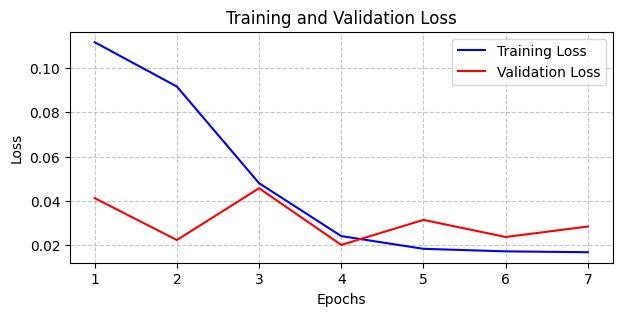

In [13]:
fig, ax = plt.subplots(figsize=(7, 3))
_ = forecaster.plot_history(ax=ax)

In [14]:
# Backtesting 
# ==============================================================================
cv = TimeSeriesFold(
         steps              = forecaster.max_step,
         initial_train_size = len(data_indexed.loc[:end_validation, :]),  # Training + Validation Data
         refit              = False
     )

# The validation partition is now used as part of the initial fit
# Epocs is set to the value idenfied in the previous training with early stopping
forecaster.set_fit_kwargs({"epochs": 8,"batch_size": 512})

metrics, predictions = backtesting_forecaster_multiseries(
    forecaster        = forecaster,
    series            = data_indexed[[TARGET_COL]],
    cv                = cv,
    levels            = forecaster.levels,
    metric            = "mean_absolute_error",
    verbose           = False,
    suppress_warnings = True
)

Epoch 1/8
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 82ms/step - loss: 0.0176
Epoch 2/8
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 86ms/step - loss: 0.0163
Epoch 3/8
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 86ms/step - loss: 0.0159
Epoch 4/8
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 87ms/step - loss: 0.0158
Epoch 5/8
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 95ms/step - loss: 0.0157
Epoch 6/8
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 90ms/step - loss: 0.0156
Epoch 7/8
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 102ms/step - loss: 0.0156
Epoch 8/8
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 147ms/step - loss: 0.0155


  0%|          | 0/1 [00:00<?, ?it/s]

In [16]:
# Plotting predictions vs real values in the test set
# ==============================================================================
fig = go.Figure()
trace1 = go.Scatter(x=data_test.index, y=data_test[TARGET_COL], name="test", mode="lines")
trace2 = go.Scatter(
    x=predictions.index,
    y=predictions.loc[predictions["level"] == TARGET_COL, "pred"],
    name="predictions", mode="lines"
)
fig.add_trace(trace1)
fig.add_trace(trace2)
fig.update_layout(
    title="Prediction vs real values in the test set",
    xaxis_title="Date time",
    yaxis_title=TARGET_COL,
    width=800,
    height=400,
    margin=dict(l=20, r=20, t=35, b=20),
    legend=dict(orientation="h", yanchor="top", y=1.05, xanchor="left", x=0)
)
fig.show()


### Adding exogenous variables

In [70]:
features_to_extract = [
    'day_of_week',
    'hour'
]
max_values = {
    "day_of_week": 7,
    "hour": 24,
}
calendar_transformer = DatetimeFeatures(
    variables           = 'index',
    features_to_extract = features_to_extract,
    drop_original       = True,
)
calendar_features = calendar_transformer.fit_transform(data_indexed)[features_to_extract]
cyclical_encoder = CyclicalFeatures(
    variables     = features_to_extract,
    max_values    = max_values,
    drop_original = False
)

exogenous_features = cyclical_encoder.fit_transform(calendar_features)
exogenous_features.head(3)

,day_of_week,hour,day_of_week_sin,day_of_week_cos,hour_sin,hour_cos
period_start,,,,,,
2026-02-01 00:00:00,6,0,-0.781831,0.62349,0.0,1.0
2026-02-01 00:15:00,6,0,-0.781831,0.62349,0.0,1.0
2026-02-01 00:30:00,6,0,-0.781831,0.62349,0.0,1.0


In [71]:
market_with_weather = add_nci(data_indexed)
market_with_weather = add_daily_clf(market_with_weather)
market_with_weather = add_rolling_3d_clf(market_with_weather)
rolling_clf = market_with_weather.set_index('period_start')[['rolling_3d_clf']]

cyclical_exog = exogenous_features.filter(regex='_sin$|_cos$')
data_exog = data_indexed[[TARGET_COL]].merge(
           cyclical_exog,
           left_index  = True,
           right_index = True,
           how         = 'inner'  # Use only dates for which we have all the variables
       )
data_exog = data_exog.merge(rolling_clf, left_index=True, right_index=True, how='inner')
data_exog = data_exog.astype('float32')
data_exog.head(5)

2026-04-24 16:07:50,418 | INFO | forecasting.features.market | Loading weather master from /Users/dhruvil/Documents/EarthSync/data/weather/weather_master.csv


,sell_bid,day_of_week_sin,day_of_week_cos,hour_sin,hour_cos,rolling_3d_clf
period_start,,,,,,
2026-02-01 00:00:00,30678.900391,-0.781832,0.62349,0.000000,1.000000,0.0
2026-02-01 00:15:00,32484.000000,-0.781832,0.62349,0.000000,1.000000,0.0
2026-02-01 00:30:00,34476.199219,-0.781832,0.62349,0.000000,1.000000,0.0
2026-02-01 00:45:00,36013.300781,-0.781832,0.62349,0.000000,1.000000,0.0
2026-02-01 01:00:00,36515.800781,-0.781832,0.62349,0.258819,0.965926,0.0


In [72]:
exog_features = exogenous_features.filter(regex='_sin$|_cos$').columns.tolist()
exog_features = exog_features + ['rolling_3d_clf']

In [73]:
data_exog_train = data_exog.loc[:end_train, :].copy()
data_exog_val = data_exog.loc[end_train:end_validation, :].copy()
data_exog_test = data_exog.loc[end_validation:, :].copy()

In [74]:
# `create_and_compile_model` with exogenous variables
# ==============================================================================
series = [TARGET_COL]
levels = [TARGET_COL]
lags = 96

model = create_and_compile_model(
    series                  = data_exog[series],         # Single-series
    levels                  = levels,                    # One target series to predict
    lags                    = lags, 
    steps                   = 96, 
    exog                    = data_exog[exog_features],  # Exogenous variables
    recurrent_layer         = "LSTM",
    recurrent_units         = [128, 64],
    recurrent_layers_kwargs = {"activation": "tanh"},
    dense_units             = [64, 32],
    compile_kwargs          = {'optimizer': Adam(learning_rate=0.01), 'loss': 'mse'},
    model_name              = "Single-Series-Multi-Step-Exog"
)

model.summary()


keras version: 3.13.2
Using backend: tensorflow
tensorflow version: 2.21.0



Model: "Single-Series-Multi-Step-Exog"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ series_input        │ (None, 96, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 96, 128)   │     66,560 │ series_input[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_2 (LSTM)       │ (None, 64)        │     49,408 │ lstm_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ repeat_vector       │ (None, 96, 64)    │          0 │ lstm_2[0][0]      │
│ (RepeatVector)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ exog_input          │ (None, 96, 5)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concat_exog         │ (None, 96, 69)    │          0 │ repeat_vector[0]… │
│ (Concatenate)       │                   │            │ exog_input[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_td_1          │ (None, 96, 64)    │      4,480 │ concat_exog[0][0] │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_td_2          │ (None, 96, 32)    │      2,080 │ dense_td_1[0][0]  │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output_dense_td_la… │ (None, 96, 1)     │         33 │ dense_td_2[0][0]  │
│ (TimeDistributed)   │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 122,561 (478.75 KB)

 Trainable params: 122,561 (478.75 KB)

 Non-trainable params: 0 (0.00 B)

In [75]:
# Forecaster Creation
# ==============================================================================
forecaster = ForecasterRnn(
    estimator=model,
    levels=levels,
    lags=lags, 
    transformer_series=MinMaxScaler(),
    transformer_exog=MinMaxScaler(),
    fit_kwargs={
        "epochs": 25, 
        "batch_size": 1024, 
        "callbacks": [
            EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True),
            ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-5, verbose=1)
        ],  # Callback to stop training when it is no longer learning and to reduce learning rate.
        "series_val": data_exog_val[series],      # Validation data for model training.
        "exog_val": data_exog_val[exog_features]  # Validation data for exogenous variables
    },
)

# Fit forecaster with exogenous variables
# ==============================================================================
forecaster.fit(
    series = data_exog_train[series], 
    exog   = data_exog_train[exog_features]
)

Epoch 1/25


/Users/dhruvil/Documents/EarthSync/es_env/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 26 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


6/6 ━━━━━━━━━━━━━━━━━━━━ 25s 3s/step - loss: 0.4085 - val_loss: 0.0817 - learning_rate: 0.0100
Epoch 2/25
6/6 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step - loss: 0.0689 - val_loss: 0.0898 - learning_rate: 0.0100
Epoch 3/25
6/6 ━━━━━━━━━━━━━━━━━━━━ 13s 2s/step - loss: 0.0501 - val_loss: 0.0592 - learning_rate: 0.0100
Epoch 4/25
6/6 ━━━━━━━━━━━━━━━━━━━━ 13s 2s/step - loss: 0.0346 - val_loss: 0.0417 - learning_rate: 0.0100
Epoch 5/25
6/6 ━━━━━━━━━━━━━━━━━━━━ 21s 4s/step - loss: 0.0285 - val_loss: 0.0324 - learning_rate: 0.0100
Epoch 6/25
6/6 ━━━━━━━━━━━━━━━━━━━━ 19s 3s/step - loss: 0.0249 - val_loss: 0.0291 - learning_rate: 0.0100
Epoch 7/25
6/6 ━━━━━━━━━━━━━━━━━━━━ 20s 3s/step - loss: 0.0222 - val_loss: 0.0242 - learning_rate: 0.0100
Epoch 8/25
6/6 ━━━━━━━━━━━━━━━━━━━━ 17s 3s/step - loss: 0.0197 - val_loss: 0.0220 - learning_rate: 0.0100
Epoch 9/25
6/6 ━━━━━━━━━━━━━━━━━━━━ 21s 3s/step - loss: 0.0175 - val_loss: 0.0192 - learning_rate: 0.0100
Epoch 10/25
6/6 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step - loss: 

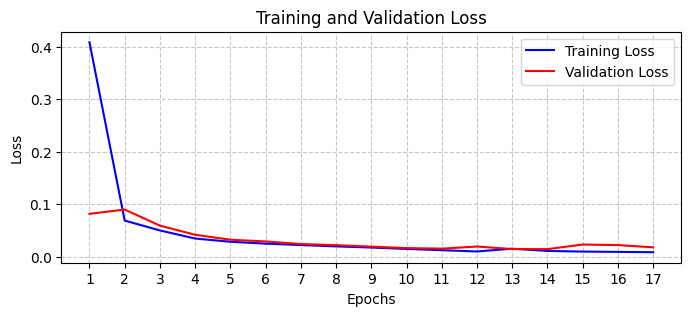

In [76]:
# Training and overfitting tracking
# ==============================================================================
fig, ax = plt.subplots(figsize=(8, 3))
_ = forecaster.plot_history(ax=ax)


In [77]:
# Backtesting with test data and exogenous variables
# ==============================================================================
cv = TimeSeriesFold(
         steps              = forecaster.max_step,
         initial_train_size = len(data_exog.loc[:end_validation, :]),  # Training + Validation Data
         refit              = False
     )

# The validation partition is now used as part of the initial fit
# Epocs is set to the value idenfied in the previous training with early stopping
forecaster.set_fit_kwargs({"epochs": 6, "batch_size": 1024})

metrics, predictions = backtesting_forecaster_multiseries(
    forecaster        = forecaster,
    series            = data_exog[series],
    exog              = data_exog[exog_features],
    cv                = cv,
    levels            = forecaster.levels,
    metric            = "mean_absolute_error",
    suppress_warnings = True,
    verbose           = False
)


Epoch 1/6
7/7 ━━━━━━━━━━━━━━━━━━━━ 25s 3s/step - loss: 0.0099
Epoch 2/6
7/7 ━━━━━━━━━━━━━━━━━━━━ 24s 3s/step - loss: 0.0099
Epoch 3/6
7/7 ━━━━━━━━━━━━━━━━━━━━ 19s 3s/step - loss: 0.0097
Epoch 4/6
7/7 ━━━━━━━━━━━━━━━━━━━━ 19s 3s/step - loss: 0.0094
Epoch 5/6
7/7 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step - loss: 0.0123
Epoch 6/6
7/7 ━━━━━━━━━━━━━━━━━━━━ 20s 3s/step - loss: 0.0124


  0%|          | 0/7 [00:00<?, ?it/s]

In [87]:
metrics

,levels,mean_absolute_error
0,00:00 - 00:15,3580.095173
1,00:15 - 00:30,3875.673912
2,00:30 - 00:45,4382.216881
3,00:45 - 01:00,5017.424498
4,01:00 - 01:15,3431.905246
...,...,...
94,23:30 - 23:45,4268.965206
95,23:45 - 24:00,4263.273326
96,average,9146.712830
97,weighted_average,9146.712830


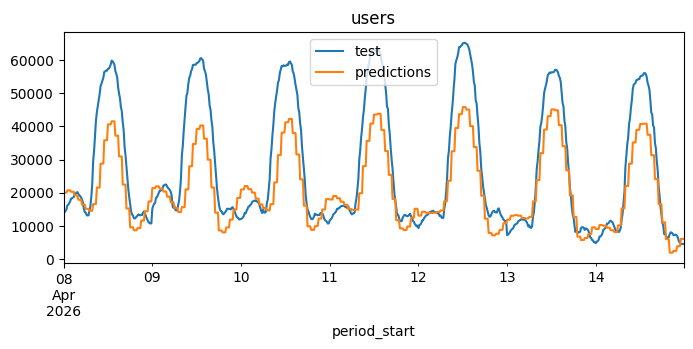

In [78]:
# Plotting predictions vs real values in the test set
# ==============================================================================
fig, ax = plt.subplots(figsize=(8, 3))
data_exog_test[TARGET_COL].plot(ax=ax, label="test")
predictions.loc[predictions["level"] == TARGET_COL, "pred"].plot(ax=ax, label="predictions")
ax.set_title("users")
ax.legend();


### Trying multiseries multioutput

In [17]:
# Trying multiseries multioutput
# Convert single-series intraday data into a daily multiseries frame (96 columns).
value_col = TARGET_COL  # or set explicitly, e.g. "purchase_bid"
# Ensure required columns are available for pivoting.
if "period" not in data_indexed.columns:
    raise ValueError("`data_indexed` must contain a `period` column like '00:00 - 00:15'.")
_multiseries_src = data_indexed[[value_col, "period"]].copy()
_multiseries_src["date"] = pd.to_datetime(_multiseries_src.index).normalize()
# Build canonical 96-block order from 15-min intervals.
# Keep the last label as 23:45 - 24:00 to match market data naming.
period_order = []
for h in range(24):
    for m in (0, 15, 30, 45):
        start_label = f"{h:02d}:{m:02d}"
        end_minutes_total = h * 60 + m + 15
        if end_minutes_total == 24 * 60:
            end_label = "24:00"
        else:
            end_h = end_minutes_total // 60
            end_m = end_minutes_total % 60
            end_label = f"{end_h:02d}:{end_m:02d}"
        period_order.append(f"{start_label} - {end_label}")
multiseries_df = (
    _multiseries_src.pivot_table(
        index="date",
        columns="period",
        values=value_col,
        aggfunc="first",
    )
    .reindex(columns=period_order)
    .sort_index()
)
multiseries_df.index.name = "date"
multiseries_df.columns.name = None
print(multiseries_df.shape)  # expected: (num_days, 96)
multiseries_df.head()


(73, 96)


,00:00 - 00:15,00:15 - 00:30,00:30 - 00:45,00:45 - 01:00,01:00 - 01:15,01:15 - 01:30,01:30 - 01:45,01:45 - 02:00,02:00 - 02:15,02:15 - 02:30,...,21:30 - 21:45,21:45 - 22:00,22:00 - 22:15,22:15 - 22:30,22:30 - 22:45,22:45 - 23:00,23:00 - 23:15,23:15 - 23:30,23:30 - 23:45,23:45 - 24:00
date,,,,,,,,,,,,,,,,,,,,,
2026-02-01,11446.6,12066.8,12510.9,12502.6,12423.8,12591.0,12324.9,12360.6,12539.3,12736.8,...,11683.5,11458.3,11664.6,11642.2,11370.3,10946.5,10966.1,10571.0,10144.4,9825.0
2026-02-02,12380.9,13084.5,13621.6,13675.3,13720.1,13707.1,13466.9,13343.4,14213.9,14481.9,...,14277.0,13985.7,13657.5,13389.6,13042.3,12740.1,12834.4,12655.0,12542.6,12383.8
2026-02-03,11816.4,12001.8,13033.6,13322.1,13459.3,13249.5,13113.8,13057.0,13188.5,13460.4,...,12935.2,12830.7,12717.5,12707.4,12557.4,12344.5,12339.9,11951.3,12029.2,11765.2
2026-02-04,12432.0,12495.4,12572.6,12582.4,12610.7,12642.9,13444.4,13328.0,13897.4,14251.1,...,14424.7,14401.9,14481.6,14663.1,14382.1,13811.6,13577.0,13296.8,13374.7,13186.0
2026-02-05,12959.9,13268.9,14280.7,14583.5,14970.5,14949.1,14725.3,14678.9,14688.2,15006.6,...,15318.1,14797.7,14809.9,14996.1,14811.0,14512.1,14100.0,13543.7,13789.2,13612.5


In [18]:
multiseries_df = multiseries_df.asfreq('d')

In [19]:
end_train = "2026-03-23"
end_validation = "2026-04-07"
multiseries_train = multiseries_df.loc[:end_train, :].copy()
multiseries_val = multiseries_df.loc[end_train:end_validation, :].copy()
multiseries_test = multiseries_df.loc[end_validation:, :].copy()

In [20]:
# Create model
# ==============================================================================
levels = multiseries_df.columns.tolist()  # Multiple target series to predict
lags = 7

model = create_and_compile_model(
    series                  = multiseries_df,    # DataFrame with all series (predictors)
    levels                  = levels, 
    lags                    = lags, 
    steps                   = 7, 
    recurrent_layer         = "LSTM",
    recurrent_units         = [128, 64],
    recurrent_layers_kwargs = {"activation": "tanh"},
    dense_units             = [64, 32],
    compile_kwargs          = {'optimizer': Adam(), 'loss': MeanSquaredError()},
    model_name              = "MultiVariate-MultiOutput-Multi-Step"
)

model.summary()


keras version: 3.13.2
Using backend: tensorflow
tensorflow version: 2.21.0



Model: "MultiVariate-MultiOutput-Multi-Step"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ series_input (InputLayer)       │ (None, 7, 96)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 7, 128)         │       115,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_dense_td_layer (Dense)   │ (None, 672)            │        22,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 7, 96)          │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 193,024 (754.00 KB)

 Trainable params: 193,024 (754.00 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
# Forecaster Creation
# ==============================================================================
forecaster = ForecasterRnn(
    estimator=model,
    levels=levels,
    lags=lags,
    transformer_series=MinMaxScaler(),
    fit_kwargs={
        "epochs": 25, 
        "batch_size": 512, 
        "callbacks": [
            EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)
        ],  # Callback to stop training when it is no longer learning.
        "series_val": multiseries_val,  # Validation data for model training.
    },
)

# Fit forecaster
# ==============================================================================
forecaster.fit(multiseries_train)

Epoch 1/25


/Users/dhruvil/Documents/EarthSync/es_env/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 26 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 0.3170 - val_loss: 0.1280
Epoch 2/25
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.3132 - val_loss: 0.1261
Epoch 3/25
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.3092 - val_loss: 0.1236
Epoch 4/25
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.3035 - val_loss: 0.1204
Epoch 5/25
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.2960 - val_loss: 0.1169
Epoch 6/25
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.2868 - val_loss: 0.1132
Epoch 7/25
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.2761 - val_loss: 0.1097
Epoch 8/25
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.2639 - val_loss: 0.1074
Epoch 9/25
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.2508 - val_loss: 0.1066
Epoch 10/25
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.2373 - val_loss: 0.1074
Epoch 11/25
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.2238 - val_loss: 0.1085
Epoch 12/25
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.2103 - val_loss: 0.1080


In [22]:
# Backtesting with test data
# ==============================================================================
cv = TimeSeriesFold(
         steps              = forecaster.max_step,
         initial_train_size = len(multiseries_df.loc[:end_validation, :]),  # Training + Validation Data
         refit              = False
     )

# The validation partition is now used as part of the initial fit
# Epocs is set to the value idenfied in the previous training with early stopping
forecaster.set_fit_kwargs({"epochs": 20, "batch_size": 512})

metrics, predictions = backtesting_forecaster_multiseries(
    forecaster        = forecaster,
    series            = multiseries_df,
    cv                = cv,
    levels            = forecaster.levels,
    metric            = "mean_absolute_error",
    suppress_warnings = True,
    verbose           = False
)


Epoch 1/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - loss: 0.2098
Epoch 2/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.1968
Epoch 3/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.1838
Epoch 4/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.1714
Epoch 5/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.1597
Epoch 6/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.1487
Epoch 7/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.1381
Epoch 8/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.1281
Epoch 9/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.1186
Epoch 10/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.1095
Epoch 11/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.1012
Epoch 12/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0937
Epoch 13/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0867
Epoch 14/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0805
Epoch 15/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0750
Epoch 16/20
1/1 ━━━━━━━━━━━━━━━━━━━━

  0%|          | 0/1 [00:00<?, ?it/s]

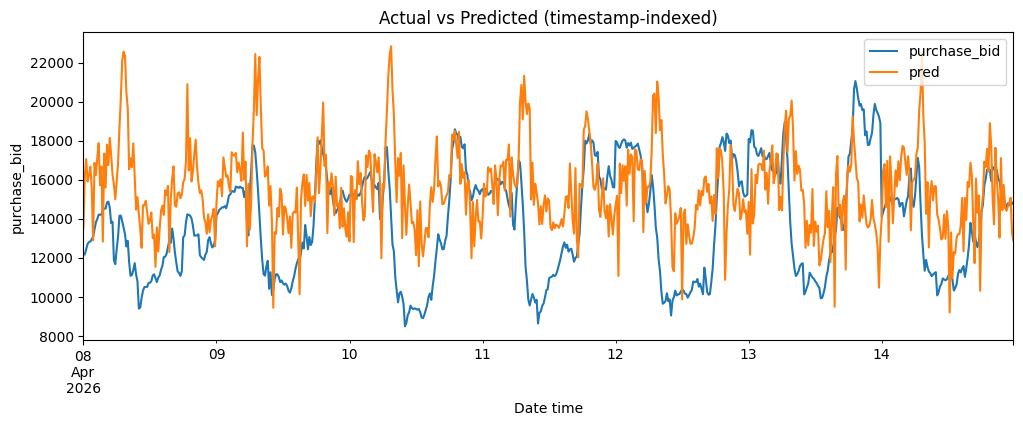

In [23]:
# Fixed version: robust conversion from multiseries predictions to timestamp-indexed frame.

def _period_start_minutes(period_label: str) -> int:
    start = period_label.split(" - ")[0]
    hh, mm = map(int, start.split(":"))
    return hh * 60 + mm

pred_wide = predictions.pivot_table(
    index=predictions.index,
    columns="level",
    values="pred",
    aggfunc="first",
)

test_start_date = pd.to_datetime(end_validation) + pd.Timedelta(days=1)
pred_wide = pred_wide.loc[pred_wide.index >= test_start_date]
actual_wide = multiseries_df.loc[multiseries_df.index >= test_start_date, pred_wide.columns]

# Ensure stack/reset_index outputs stable column names: date, period.
pred_long = (
    pred_wide.rename_axis(index="date", columns="period")
    .stack()
    .reset_index(name="pred")
)
actual_long = (
    actual_wide.rename_axis(index="date", columns="period")
    .stack()
    .reset_index(name=TARGET_COL)
)

pred_long["timestamp"] = pd.to_datetime(pred_long["date"]) + pd.to_timedelta(
    pred_long["period"].map(_period_start_minutes), unit="m"
)
actual_long["timestamp"] = pd.to_datetime(actual_long["date"]) + pd.to_timedelta(
    actual_long["period"].map(_period_start_minutes), unit="m"
)

pred_long = pred_long.set_index("timestamp").sort_index()
actual_long = actual_long.set_index("timestamp").sort_index()

compare_test = actual_long[[TARGET_COL]].join(pred_long[["pred"]], how="inner")
compare_test.head()

ax = compare_test[[TARGET_COL, "pred"]].plot(
    figsize=(12, 4),
    title="Actual vs Predicted (timestamp-indexed)",
)
ax.set_xlabel("Date time")
ax.set_ylabel(TARGET_COL)
plt.show()

In [24]:
# MAE on timestamp-aligned test comparison dataframe
mae = (compare_test[TARGET_COL] - compare_test["pred"]).abs().mean()
print(f"MAE: {mae:.4f}")

MAE: 2687.3030


In [25]:
pred_long.reset_index().drop(columns=["date", "period"]).to_csv(f"../../../data/predictions/{LAG_SUFFIX}_lstm_0408_0414.csv")